# RL-12 : Distributional RL — C51 (Categorical DQN) depuis zero

**Serie** : Reinforcement Learning | **Notebook** : 12/13 | **Duree estimee** : 50-55 min

Navigation : [RL-5 Tabulaire](rl_5_mdp_dp_qlearning.ipynb) | [RL-6 DQN](rl_6_dqn_policy_gradient.ipynb) | [RL-6d SAC](rl_6d_sac_from_scratch.ipynb) | **RL-12** | [RL-9 Offline](rl_9_offline_rl.ipynb)

---

## Objectifs d'apprentissage

A la fin de ce notebook, vous serez capable de :
- Comprendre **pourquoi modeliser la distribution complete du retour** $Z(s,a)$ plutot que sa seule esperance $Q(s,a) = \mathbb{E}[Z(s,a)]$.
- Implementer **C51** (Categorical DQN, Bellemare et al. 2017) depuis zero : support categoriel a atomes fixes, reseau a sorties softmax, **projection categorielle** de la cible de Bellman distributionnelle.
- Entrainer C51 sur CartPole-v1 et **visualiser la distribution de retour apprise** par action.
- Situer C51 dans la lignee QR-DQN / IQN / Rainbow et comprendre l'interet pour le **RL sensible au risque**.

## Prerequis

- [RL-6 DQN depuis zero](rl_6_dqn_policy_gradient.ipynb) : replay buffer, target network, $\varepsilon$-greedy, equation de Bellman pour $Q$.
- [RL-5 MDP / Q-Learning](rl_5_mdp_dp_qlearning.ipynb) : retour, facteur d'actualisation $\gamma$, equation de Bellman.
- Bases de PyTorch (tenseurs, autograd, `nn.Module`).

---

**Pourquoi modeliser la distribution complete ?**

Le DQN classique apprend une **esperance** : $Q(s,a) = \mathbb{E}\big[\sum_t \gamma^t r_t \mid s, a\big]$. Or deux actions peuvent avoir la **meme moyenne** mais des **risques tres differents** : l'une garantit un retour moyen, l'autre alterne jackpots et catastrophes. L'esperance ecrase cette information.

Le **RL distributionnel** apprend la **variable aleatoire de retour** $Z(s,a)$ tout entiere, pas seulement sa moyenne. Bellemare, Dabney & Munos (2017) montrent que cet objectif plus riche **stabilise et accelere** l'apprentissage (C51 fut un ingredient cle de *Rainbow*), et qu'il **debloque des politiques sensibles au risque** (choisir selon une CVaR, un quantile bas, etc.). Ce notebook construit C51 brique par brique.

## 1. Setup et imports

C51 ne demande que NumPy, PyTorch (CPU suffit) et Gymnasium pour CartPole-v1 — le meme environnement que [RL-6](rl_6_dqn_policy_gradient.ipynb), ce qui permet une comparaison directe avec le DQN scalaire.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
from collections import deque
import random
import matplotlib.pyplot as plt

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cpu")  # un MLP a 2 couches sur CartPole tourne tres bien sur CPU
print("torch", torch.__version__, "| gymnasium", gym.__version__, "| device", device)

torch 2.11.0+cpu | gymnasium 1.2.3 | device cpu


## 2. Du scalaire $Q(s,a)$ a la distribution $Z(s,a)$

C51 ne predit pas un nombre, mais une **distribution de probabilite discrete** sur un **support fixe** de $N=51$ valeurs (les *atomes*) :

$$z_i = V_{\min} + i\,\Delta z,\qquad \Delta z = \frac{V_{\max}-V_{\min}}{N-1},\qquad i = 0,\dots,N-1.$$

Pour un couple $(s,a)$, le reseau sort des probabilites $p_i(s,a)$ avec $\sum_i p_i = 1$. L'esperance se reconstruit trivialement :

$$Q(s,a) = \mathbb{E}[Z(s,a)] = \sum_{i=0}^{N-1} z_i\, p_i(s,a).$$

Le support doit **couvrir l'amplitude reelle des retours**. Sur CartPole-v1 (recompense $+1$ par pas, episode $\le 500$ pas, $\gamma=0{,}99$), le retour actualise vaut au plus $\sum_{t\ge0}\gamma^t \approx 100$ ; on prend une marge avec $[V_{\min}, V_{\max}] = [0, 200]$.

51 atomes de 0.0 a 200.0, pas delta_z = 4.00


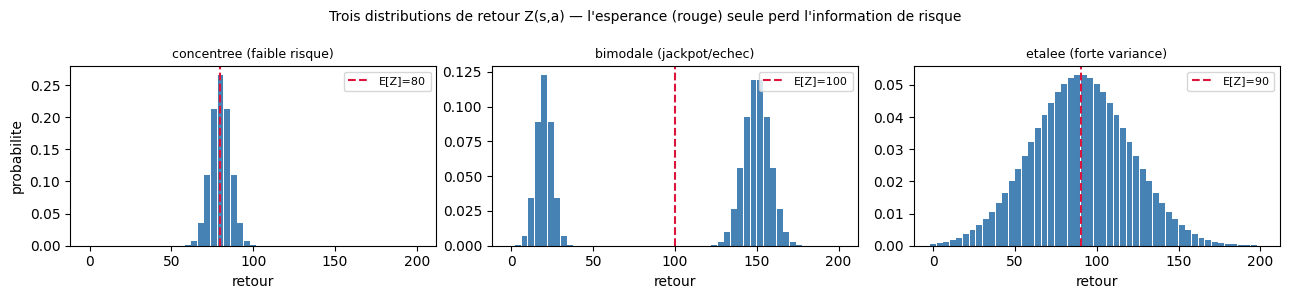

In [2]:
N_ATOMS = 51
V_MIN, V_MAX = 0.0, 200.0
GAMMA = 0.99

support = torch.linspace(V_MIN, V_MAX, N_ATOMS, device=device)   # z_i
delta_z = (V_MAX - V_MIN) / (N_ATOMS - 1)
print(f"{N_ATOMS} atomes de {V_MIN} a {V_MAX}, pas delta_z = {delta_z:.2f}")

# Exemple : trois distributions de meme support, esperances differentes
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
demo = {
    "concentree (faible risque)": torch.exp(-0.5 * ((support - 80) / 6) ** 2),
    "bimodale (jackpot/echec)":   torch.exp(-0.5 * ((support - 20) / 5) ** 2) + torch.exp(-0.5 * ((support - 150) / 8) ** 2),
    "etalee (forte variance)":    torch.exp(-0.5 * ((support - 90) / 30) ** 2),
}
for a, (title, p) in zip(ax, demo.items()):
    p = (p / p.sum())
    a.bar(support.numpy(), p.numpy(), width=delta_z * 0.9, color="steelblue")
    a.axvline((support * p).sum().item(), color="crimson", ls="--", label=f"E[Z]={(support*p).sum().item():.0f}")
    a.set_title(title, fontsize=9); a.set_xlabel("retour"); a.legend(fontsize=8)
ax[0].set_ylabel("probabilite")
plt.suptitle("Trois distributions de retour Z(s,a) — l'esperance (rouge) seule perd l'information de risque", fontsize=10)
plt.tight_layout(); plt.show()

## 3. L'equation de Bellman distributionnelle et la projection categorielle

L'operateur de Bellman distributionnel transporte la distribution de retour :

$$T Z(s,a) \;\stackrel{D}{=}\; R(s,a) + \gamma\, Z(s', a^\*),\qquad a^\* = \arg\max_{a'} Q(s', a').$$

Probleme : appliquer $z \mapsto r + \gamma z$ **deplace les atomes hors du support fixe** $\{z_i\}$. C51 resout cela par une **projection categorielle** $\Phi$ : on clippe chaque atome transforme $\hat{T}z_j = \mathrm{clip}(r + \gamma z_j,\, V_{\min}, V_{\max})$, on calcule sa position fractionnaire $b_j = (\hat{T}z_j - V_{\min})/\Delta z$, et on **repartit sa masse de probabilite** sur les deux atomes voisins $\lfloor b_j\rfloor$ et $\lceil b_j\rceil$ au prorata de la distance. La perte est ensuite l'**entropie croisee** entre la cible projetee et la distribution predite.

### 3.1 Implementation et illustration de la projection

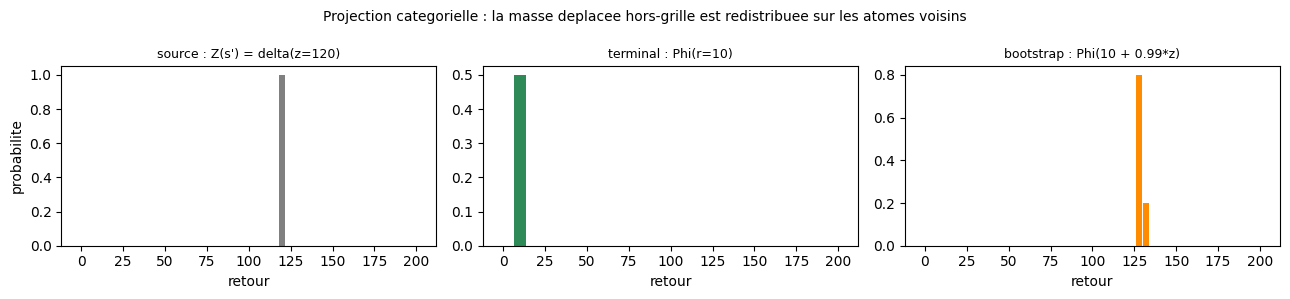

sommes des distributions projetees (doivent valoir 1): 1.0 1.0


In [3]:
def project(next_dist, rewards, dones):
    """Projection categorielle Phi de la cible de Bellman distributionnelle sur le support fixe.
    next_dist : (B, N_ATOMS) distribution de l'action greedy a l'etat suivant
    rewards   : (B,)  | dones : (B,) flag terminal (1.0 si etat terminal reel)
    retourne  : (B, N_ATOMS) distribution cible projetee m."""
    B = rewards.size(0)
    # Tz_j = r + gamma * z_j  (pas de bootstrap si terminal), puis clip sur [V_MIN, V_MAX]
    Tz = rewards.unsqueeze(1) + (1 - dones).unsqueeze(1) * GAMMA * support.unsqueeze(0)
    Tz = Tz.clamp(V_MIN, V_MAX)
    b = (Tz - V_MIN) / delta_z                  # position fractionnaire sur le support
    lo = b.floor().long(); up = b.ceil().long()
    # cas ou b tombe exactement sur un entier : eviter de perdre la masse
    lo[(up > 0) & (lo == up)] -= 1
    up[(lo < (N_ATOMS - 1)) & (lo == up)] += 1
    m = torch.zeros(B, N_ATOMS, device=device)
    offset = (torch.arange(B, device=device) * N_ATOMS).unsqueeze(1)
    # masse vers l'atome bas (proportionnelle a la distance a l'atome haut) et vers l'atome haut
    m.view(-1).index_add_(0, (lo + offset).view(-1), (next_dist * (up.float() - b)).view(-1))
    m.view(-1).index_add_(0, (up + offset).view(-1), (next_dist * (b - lo.float())).view(-1))
    return m

# Illustration : une distribution concentree a l'etat suivant, projetee apres Tz = r + gamma*z
src = torch.zeros(1, N_ATOMS); src[0, 30] = 1.0  # masse unitaire sur l'atome 30 (z=120)
proj_term = project(src, torch.tensor([10.0]), torch.tensor([1.0]))   # terminal : cible = r seul
proj_boot = project(src, torch.tensor([10.0]), torch.tensor([0.0]))   # bootstrap : cible = r + gamma*z
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
ax[0].bar(support.numpy(), src[0].numpy(), width=delta_z*0.9, color="gray");   ax[0].set_title(f"source : Z(s') = delta(z={support[30]:.0f})", fontsize=9)
ax[1].bar(support.numpy(), proj_term[0].numpy(), width=delta_z*0.9, color="seagreen"); ax[1].set_title("terminal : Phi(r=10)", fontsize=9)
ax[2].bar(support.numpy(), proj_boot[0].numpy(), width=delta_z*0.9, color="darkorange"); ax[2].set_title(f"bootstrap : Phi(10 + {GAMMA}*z)", fontsize=9)
for a in ax: a.set_xlabel("retour")
ax[0].set_ylabel("probabilite")
plt.suptitle("Projection categorielle : la masse deplacee hors-grille est redistribuee sur les atomes voisins", fontsize=10)
plt.tight_layout(); plt.show()
print("sommes des distributions projetees (doivent valoir 1):", round(proj_term.sum().item(),4), round(proj_boot.sum().item(),4))

## 4. Implementation de C51

### 4.1 Le reseau `CategoricalDQN`

Le reseau prend l'etat et sort $N_{\text{actions}} \times N_{\text{atoms}}$ logits, organises par action. Un `softmax` sur la derniere dimension donne, pour chaque action, une distribution de probabilite valide sur le support.

In [4]:
class CategoricalDQN(nn.Module):
    def __init__(self, obs_dim, n_actions, n_atoms):
        super().__init__()
        self.n_actions, self.n_atoms = n_actions, n_atoms
        self.body = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, n_actions * n_atoms),
        )

    def dist(self, x):
        """(B, n_actions, n_atoms) : une distribution de proba par action."""
        logits = self.body(x).view(-1, self.n_actions, self.n_atoms)
        return F.softmax(logits, dim=-1)

    def q(self, x):
        """(B, n_actions) : esperances Q(s,a) = sum_i z_i p_i(s,a)."""
        return (self.dist(x) * support).sum(-1)

# verification rapide des formes
_net = CategoricalDQN(4, 2, N_ATOMS)
_d = _net.dist(torch.zeros(3, 4))
print("dist shape:", tuple(_d.shape), "| somme par (etat,action) ~1:", _d.sum(-1).mean().item())
print("q shape:", tuple(_net.q(torch.zeros(3, 4)).shape))

dist shape: (3, 2, 51) | somme par (etat,action) ~1: 1.0
q shape: (3, 2)


### 4.2 Replay buffer et selection d'action

Comme pour le DQN, on decorrele les transitions via un **replay buffer**, et on agit en $\varepsilon$-greedy sur l'esperance $Q(s,a)=\sum_i z_i p_i(s,a)$. La difference est interne : ce qui est appris est la **distribution**, pas le scalaire.

In [5]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buf = deque(maxlen=capacity)
    def push(self, *t):
        self.buf.append(t)
    def sample(self, n):
        batch = random.sample(self.buf, n)
        s, a, r, ns, d = zip(*batch)
        return (torch.tensor(np.array(s), dtype=torch.float32, device=device),
                torch.tensor(a, device=device),
                torch.tensor(r, dtype=torch.float32, device=device),
                torch.tensor(np.array(ns), dtype=torch.float32, device=device),
                torch.tensor(d, dtype=torch.float32, device=device))
    def __len__(self):
        return len(self.buf)

def select_action(net, obs, eps, n_actions):
    if random.random() < eps:
        return random.randrange(n_actions)
    with torch.no_grad():
        return int(net.q(torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)).argmax(1).item())

print("ReplayBuffer et select_action prets.")

ReplayBuffer et select_action prets.


### 4.3 La perte distributionnelle

A chaque pas d'apprentissage :
1. on choisit l'action greedy $a^\*$ a l'etat suivant **selon l'esperance du target network** ;
2. on recupere sa distribution $p(s', a^\*)$ et on la **projette** via $\Phi$ pour obtenir la cible $m$ ;
3. la perte est l'**entropie croisee** $-\sum_i m_i \log p_i(s,a)$ entre cible projetee et distribution predite pour l'action jouee.

In [6]:
def compute_loss(online, target, batch):
    s, a, r, ns, d = batch
    B = s.size(0)
    with torch.no_grad():
        next_a = target.q(ns).argmax(1)                       # action greedy (esperance) a s'
        next_dist = target.dist(ns)[torch.arange(B, device=device), next_a]   # (B, atoms)
        m = project(next_dist, r, d)                          # cible projetee
    dist = online.dist(s)[torch.arange(B, device=device), a]  # (B, atoms) action jouee
    loss = -(m * torch.log(dist.clamp(min=1e-8))).sum(1).mean()   # entropie croisee
    return loss

print("Perte distributionnelle (entropie croisee sur cible projetee) prete.")

Perte distributionnelle (entropie croisee sur cible projetee) prete.


## 5. Entrainement sur CartPole-v1

On entraine sur un budget court (~18 000 pas, quelques minutes sur CPU). Les hyperparametres sont volontairement proches de ceux du DQN de [RL-6](rl_6_dqn_policy_gradient.ipynb) pour que la comparaison porte sur l'objectif (distribution vs esperance), pas sur le reglage.

In [7]:
def train_c51(max_steps=18000, seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    env = gym.make("CartPole-v1")
    obs_dim = env.observation_space.shape[0]; n_actions = env.action_space.n
    online = CategoricalDQN(obs_dim, n_actions, N_ATOMS).to(device)
    target = CategoricalDQN(obs_dim, n_actions, N_ATOMS).to(device)
    target.load_state_dict(online.state_dict())
    opt = torch.optim.Adam(online.parameters(), lr=1e-3)
    buf = ReplayBuffer(20000)

    BATCH, MIN_BUF, TARGET_SYNC = 64, 1000, 500
    EPS_START, EPS_END, EPS_DECAY = 1.0, 0.05, 8000

    returns, ep_ret, step = [], 0.0, 0
    obs, _ = env.reset(seed=seed)
    while step < max_steps:
        eps = EPS_END + (EPS_START - EPS_END) * np.exp(-step / EPS_DECAY)
        a = select_action(online, obs, eps, n_actions)
        nobs, r, term, trunc, _ = env.step(a)
        buf.push(obs, a, r, nobs, float(term))   # bootstrap uniquement sur terminal reel
        obs = nobs; ep_ret += r; step += 1
        if term or trunc:
            returns.append(ep_ret); ep_ret = 0.0
            obs, _ = env.reset()
        if len(buf) >= MIN_BUF:
            loss = compute_loss(online, target, buf.sample(BATCH))
            opt.zero_grad(); loss.backward(); opt.step()
        if step % TARGET_SYNC == 0:
            target.load_state_dict(online.state_dict())
    env.close()
    return online, returns

online_net, returns = train_c51()
print(f"Episodes joues : {len(returns)}")
print(f"Retour moyen 20 premiers episodes : {np.mean(returns[:20]):.1f}")
print(f"Retour moyen 20 derniers episodes : {np.mean(returns[-20:]):.1f}")
print(f"Retour maximum atteint : {max(returns):.0f}")

Episodes joues : 308
Retour moyen 20 premiers episodes : 21.8
Retour moyen 20 derniers episodes : 115.8
Retour maximum atteint : 328


### 5.1 Courbe d'apprentissage

Le retour par episode doit grimper nettement au-dessus de la baseline aleatoire (~20 pas) : C51 apprend a equilibrer le pendule.

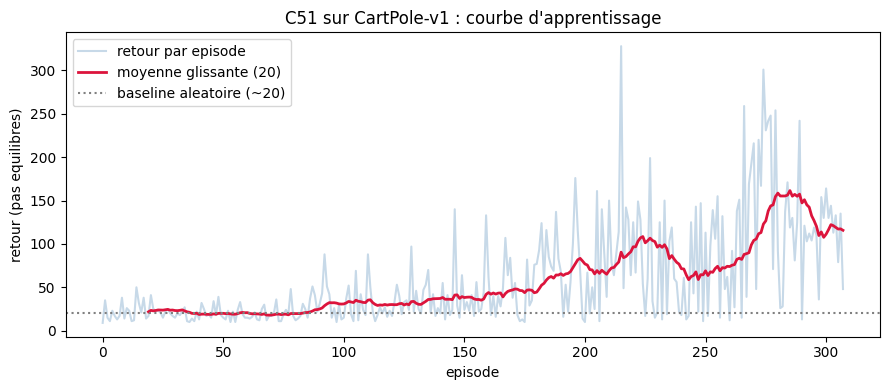

In [8]:
def moving_avg(x, k=20):
    if len(x) < k: return np.array(x)
    return np.convolve(x, np.ones(k) / k, mode="valid")

plt.figure(figsize=(9, 4))
plt.plot(returns, alpha=0.3, color="steelblue", label="retour par episode")
plt.plot(np.arange(len(moving_avg(returns))) + 19, moving_avg(returns), color="crimson", lw=2, label="moyenne glissante (20)")
plt.axhline(20, color="gray", ls=":", label="baseline aleatoire (~20)")
plt.xlabel("episode"); plt.ylabel("retour (pas equilibres)")
plt.title("C51 sur CartPole-v1 : courbe d'apprentissage"); plt.legend(); plt.tight_layout(); plt.show()

### 5.2 La vraie valeur ajoutee : la distribution de retour apprise

C'est ici que C51 se distingue d'un DQN. Pour un etat donne, on n'a pas seulement deux scalaires $Q(s,\text{gauche})$ et $Q(s,\text{droite})$ : on a **deux distributions completes**. On peut lire la moyenne (la fleche), mais aussi la dispersion, la dissymetrie, les modes — l'information qu'un DQN scalaire jette.

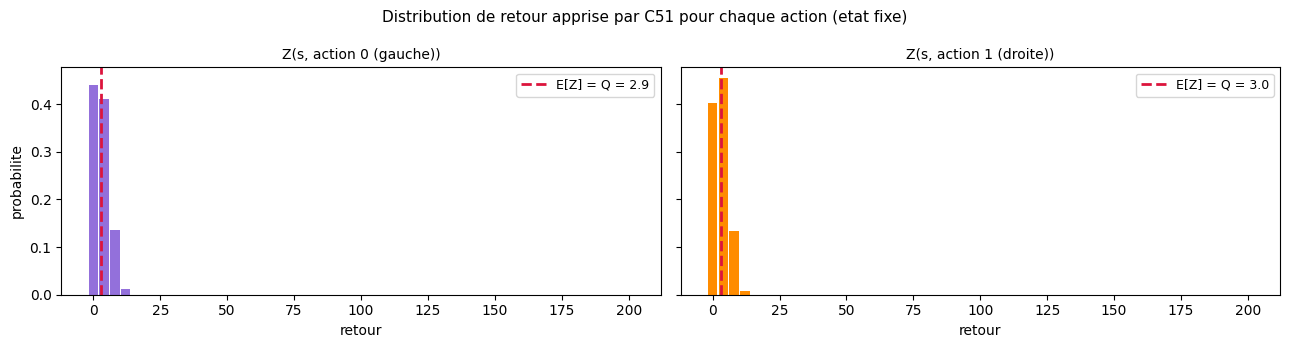

Action choisie par la politique greedy (argmax E[Z]) : 1 (action 1 (droite))


In [9]:
env = gym.make("CartPole-v1")
obs, _ = env.reset(seed=123)
for _ in range(10):   # avancer un peu pour un etat non trivial
    obs, _, term, trunc, _ = env.step(env.action_space.sample())
    if term or trunc: obs, _ = env.reset(seed=123)
env.close()

with torch.no_grad():
    d = online_net.dist(torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0))[0]  # (n_actions, atoms)
    q = online_net.q(torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0))[0]

labels = ["action 0 (gauche)", "action 1 (droite)"]
colors = ["mediumpurple", "darkorange"]
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
for i in range(2):
    ax[i].bar(support.numpy(), d[i].numpy(), width=delta_z * 0.9, color=colors[i])
    ax[i].axvline(q[i].item(), color="crimson", ls="--", lw=2, label=f"E[Z] = Q = {q[i].item():.1f}")
    ax[i].set_title(f"Z(s, {labels[i]})", fontsize=10); ax[i].set_xlabel("retour"); ax[i].legend(fontsize=9)
ax[0].set_ylabel("probabilite")
plt.suptitle("Distribution de retour apprise par C51 pour chaque action (etat fixe)", fontsize=11)
plt.tight_layout(); plt.show()
print(f"Action choisie par la politique greedy (argmax E[Z]) : {int(q.argmax().item())} ({labels[int(q.argmax().item())]})")

## 6. C51 vs DQN : que gagne-t-on ?

| Aspect | DQN ([RL-6](rl_6_dqn_policy_gradient.ipynb)) | C51 (ce notebook) |
|--------|------|-----|
| Sortie par action | un scalaire $Q(s,a)$ | une distribution $p(s,a)$ sur 51 atomes |
| Cible de Bellman | $r + \gamma \max_{a'} Q(s',a')$ | $\Phi\big(r + \gamma Z(s',a^\*)\big)$ (projetee) |
| Perte | erreur quadratique (Huber) | entropie croisee distributionnelle |
| Information apprise | esperance seule | esperance **+ variance, modes, asymetrie** |
| Politique greedy | $\arg\max_a Q$ | $\arg\max_a \mathbb{E}[Z]$ (mais on peut faire mieux : voir Exercice 3) |

Empiriquement, l'objectif distributionnel fournit un **signal d'apprentissage plus riche** (chaque atome est une cible) qui stabilise souvent l'entrainement — C51 fut l'un des six ingredients de **Rainbow** (Hessel et al. 2018). Surtout, disposer de la distribution permet des **politiques sensibles au risque** que l'esperance seule rend impossibles.

**La lignee distributionnelle** : C51 fixe le support et apprend les probabilites. **QR-DQN** (Dabney et al. 2018) inverse le probleme — il fixe les probabilites ($N$ quantiles equiprobables) et **apprend les positions** (les valeurs des quantiles), evitant la projection. **IQN** echantillonne les quantiles a la volee. L'Exercice 1 explore ce basculement.

## 7. Exercices

Trois exercices pour approfondir. Les cellules de code sont des **squelettes a completer** : le notebook s'execute de bout en bout meme sans les remplir.

### Exercice 1 : QR-DQN (quantile regression)

C51 fixe les atomes et apprend leurs probabilites. **QR-DQN** fait l'inverse : il fixe $N$ probabilites egales ($1/N$ chacune) et apprend les **valeurs** des quantiles $\theta_i(s,a)$. Avantages : plus de support a regler, plus de projection.

Implementez l'estimation de l'esperance pour QR-DQN et l'esquisse de la **perte de Huber quantile** (quantile midpoints $\hat\tau_i = (i + 0{,}5)/N$). Indice : $Q(s,a) = \frac{1}{N}\sum_i \theta_i(s,a)$ ; la perte pondere l'erreur $\theta_i - \text{cible}$ par $|\hat\tau_i - \mathbb{1}[\text{erreur} < 0]|$.

In [10]:
# Exercice 1 : QR-DQN — a completer
N_QUANTILES = 51

def qrdqn_quantile_midpoints(n):
    # TODO etudiant : retourner les tau_hat_i = (i + 0.5) / n,  i = 0..n-1  (tenseur (n,))
    return None  # remplacer par : (torch.arange(n, dtype=torch.float32) + 0.5) / n

def qrdqn_expected_q(theta):
    # theta : (B, n_actions, N_QUANTILES) valeurs de quantiles apprises
    # TODO etudiant : Q(s,a) = moyenne des quantiles sur la derniere dimension
    pass  # indice : return theta.mean(-1)

# Indice perte : huber(theta_i - target_j) * |tau_hat_i - 1{theta_i - target_j < 0}|, moyennee
print("Exercice 1 a completer : QR-DQN apprend les positions des quantiles, pas leurs probabilites.")

Exercice 1 a completer : QR-DQN apprend les positions des quantiles, pas leurs probabilites.


### Exercice 2 : Sensibilite au support $[V_{\min}, V_{\max}]$

Le support categoriel doit **encadrer les retours reels**. Trop etroit, la masse sature aux bords (information perdue) ; trop large, la resolution $\Delta z$ se degrade. Relancez `train_c51` avec des supports mal regles et comparez les courbes d'apprentissage.

Completez la fonction qui, pour un $(V_{\min}, V_{\max})$ donne, renvoie le pas $\Delta z$ et signale si le retour theorique max de CartPole (~100 sous $\gamma=0{,}99$) **depasse** $V_{\max}$.

In [11]:
# Exercice 2 : diagnostic de support — a completer
def support_diagnostic(v_min, v_max, n_atoms=51, gamma=0.99, max_episode_len=500):
    # retour actualise theorique max de CartPole : sum_{t=0}^{T-1} gamma^t
    theo_max = (1 - gamma ** max_episode_len) / (1 - gamma)
    # TODO etudiant : calculer delta_z et le booleen "support trop etroit" (theo_max > v_max)
    result = None  # remplacer par : {"delta_z": (v_max - v_min)/(n_atoms-1), "trop_etroit": theo_max > v_max, "theo_max": theo_max}
    return result

# Piste d'experience : for (vmin, vmax) in [(0,50),(0,200),(0,1000)]: online,_ = train_c51(max_steps=8000); ...
print("Exercice 2 a completer : un support mal cale brise l'apprentissage distributionnel.")

Exercice 2 a completer : un support mal cale brise l'apprentissage distributionnel.


### Exercice 3 : Politique sensible au risque

La politique greedy de C51 choisit $\arg\max_a \mathbb{E}[Z(s,a)]$ — elle ignore le risque, comme un DQN. Mais nous avons la **distribution complete** ! Implementez une politique **CVaR** (Conditional Value at Risk) : au lieu de la moyenne, evaluez chaque action par la moyenne de sa **queue basse** (les $\alpha$% pires retours), et choisissez l'action qui maximise cette valeur conservatrice. C'est impossible avec un DQN scalaire — c'est tout l'interet du RL distributionnel.

In [12]:
# Exercice 3 : politique CVaR sensible au risque — a completer
def cvar_action(net, obs, alpha=0.25):
    """Choisit l'action maximisant la CVaR_alpha (moyenne des alpha% pires retours)."""
    with torch.no_grad():
        d = net.dist(torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0))[0]  # (n_actions, atoms)
    # TODO etudiant : pour chaque action, cumuler les probas sur le support trie croissant,
    # garder la masse jusqu'au quantile alpha, calculer l'esperance conditionnelle (CVaR),
    # puis retourner argmax_a CVaR_a.
    # Indice : cdf = d.cumsum(-1) ; masque = cdf <= alpha ; cvar = (support * d * masque).sum(-1) / (d * masque).sum(-1)
    return None  # remplacer par l'argmax des CVaR par action

print("Exercice 3 a completer : la distribution permet une politique averse au risque (CVaR), hors de portee d'un DQN.")

Exercice 3 a completer : la distribution permet une politique averse au risque (CVaR), hors de portee d'un DQN.


## Application : retours sensibles au risque en finance et en sante

Le RL distributionnel n'est pas qu'une elegance theorique. Partout ou **la queue de distribution compte autant que la moyenne**, il devient indispensable :

- **Finance / trading algorithmique** : deux strategies de meme rendement espere mais de drawdown tres different ne sont pas equivalentes. Une politique CVaR (cf. Exercice 3) privilegie les strategies dont les pires scenarios restent acceptables — exactement le critere d'un gestionnaire de risque. Voir la serie [QuantConnect](../QuantConnect/README.md).
- **Sante / dosage** : un traitement de meme efficacite moyenne mais a variance letale est a proscrire ; la distribution de retour encode ce risque.
- **Robotique / conduite autonome** : eviter les rares catastrophes prime sur l'optimisation du cas moyen.

C'est aussi un pont vers les methodes modernes : la distribution de retour est au coeur d'**IQN**, de la composante distributionnelle de **Rainbow**, et des approches recentes de RL robuste.

## Conclusion

Vous avez construit **C51 depuis zero** : support categoriel a atomes fixes, reseau a sorties softmax par action, **projection categorielle** de la cible de Bellman distributionnelle, et perte d'entropie croisee. Sur CartPole-v1, l'agent apprend a equilibrer le pendule **tout en exposant la distribution complete du retour** par action.

### Points cles a retenir
- Le RL distributionnel apprend $Z(s,a)$ (la variable aleatoire), pas seulement $Q(s,a) = \mathbb{E}[Z(s,a)]$.
- C51 discretise $Z$ sur un **support fixe** ; la **projection categorielle** est ce qui rend l'apprentissage realisable sur cette grille.
- L'objectif distributionnel donne un signal plus riche (stabilisation, ingredient de Rainbow) et **debloque les politiques sensibles au risque** (CVaR), impossibles avec un DQN scalaire.
- **QR-DQN** est le pendant naturel : apprendre les positions de quantiles equiprobables plutot que les probabilites d'atomes fixes.

### Pour aller plus loin
- [RL-6 DQN](rl_6_dqn_policy_gradient.ipynb) : le point de depart scalaire, a comparer directement.
- [RL-6d SAC](rl_6d_sac_from_scratch.ipynb) : RL a entropie maximale (autre forme d'enrichissement de l'objectif).
- [RL-9 Offline](rl_9_offline_rl.ipynb) : la distribution de retour aide a quantifier l'incertitude hors-ligne.

### References
- Bellemare, Dabney & Munos (2017), *A Distributional Perspective on Reinforcement Learning*, ICML (C51).
- Dabney, Rowland, Bellemare & Munos (2018), *Distributional RL with Quantile Regression*, AAAI (QR-DQN).
- Hessel et al. (2018), *Rainbow: Combining Improvements in Deep RL*, AAAI.